# Regresión lineal

En este notebook trabajaremos con datos simulados para estudiar:

- cómo se ajusta una regresión lineal
- cómo se evalúa un modelo de regresión
- cómo cambia el ajuste frente a outliers
- cómo funciona Gradient Descent
- cómo Ridge, Lasso y Elastic Net modifican los coeficientes.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)



## Instrucciones

Este notebook combina celdas demostrativas con preguntas de análisis.

No basta con ejecutar el código: deben interpretar los resultados, comparar métricas y justificar sus respuestas usando gráficos, coeficientes y residuos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model # Nuevo modelo desbloqueado

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14)
matplotlib.rc('ytick', labelsize=14)
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

In [2]:
from sklearn.metrics._scorer import _SCORERS

#### Generamos un dataset de juguete

Primero trabajaremos con datos simulados. La ventaja es que conocemos la relación verdadera:
$$
y_{\rm true} = 3x + 3
$$

Luego agregamos ruido para simular mediciones imperfectas.

In [3]:
np.random.seed(16) #fijar semilla para la reproducibilidad

x = np.arange(100)

yp = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3))
#genera datos con dispersión, siguiendo una distribución Poissoniana
# con valor esperado = y (modelo lineal), centrado alrededor de cero

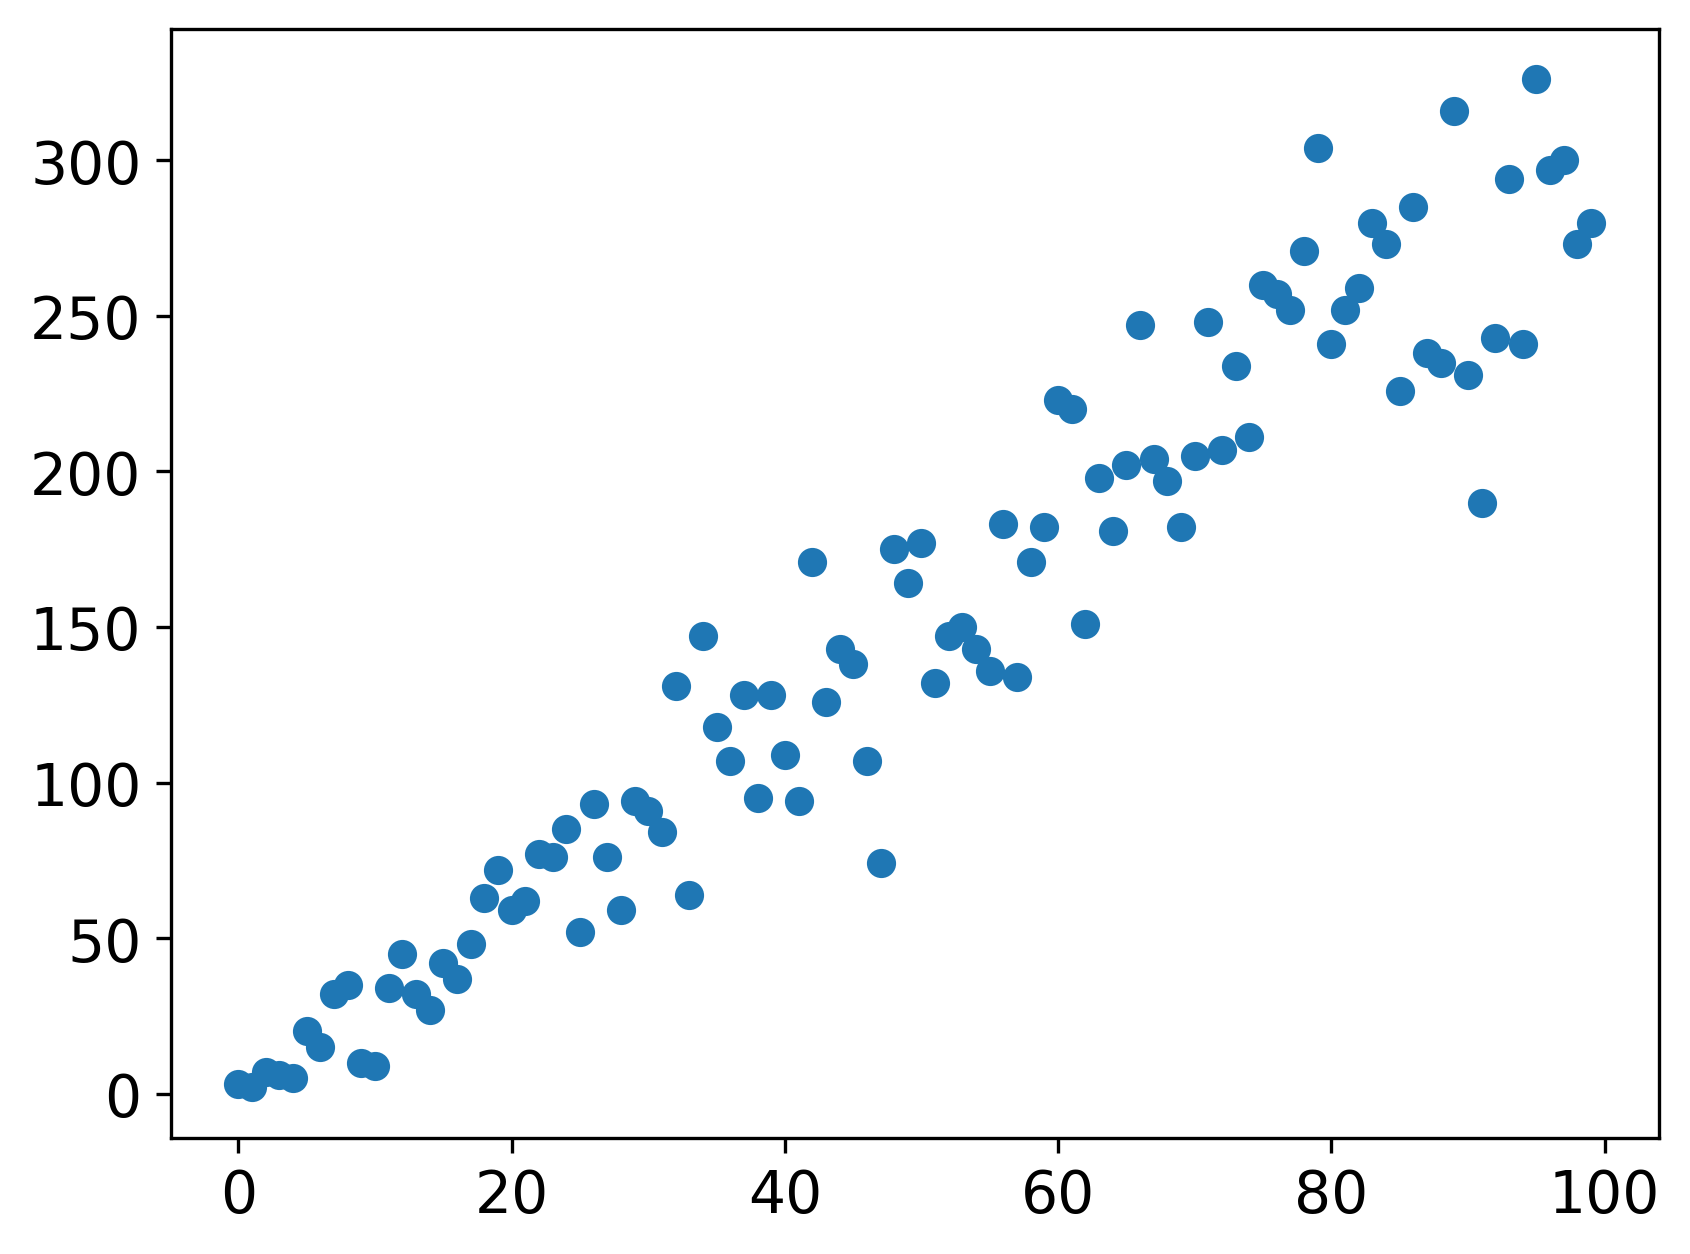

In [4]:
plt.scatter(x, yp);

### Pregunta

De acuerdo al gráfico anterior:
- ¿Los datos siguen una tendencia aproximadamente lineal?

Sí, los datos siguen una tendencia aproximadamente lineal.

- ¿La dispersión alrededor de la recta parece constante para todos los valores de \(x\)?

No, la dispersión alrededor de la recta no parece ser constante.

- ¿Qué podría implicar esto al mirar residuos más adelante?

Esto implica que cuando grafiquemos los residuos con x, esperamos ver un patrón en forma de "cono" o "abanico". Los residuos tenderán a ser más pequeños y agrupados cerca de cero para valores pequeños de x, y se dispersarán más para valores grandes de x. Esto indica de que el modelo de regresión lineal podría no ser el mejor para capturar la varianza de los datos, o que la varianza del error no es constante.

In [5]:
model = linear_model.LinearRegression()

#### Ajuste con regresión lineal

Ajustaremos un modelo de la forma:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

En `sklearn`, cuando tenemos una sola feature, necesitamos escribir `x` como una matriz de forma `(n_samples, 1)`. Por eso usamos:

```python
x.reshape(-1, 1)

In [6]:
model.fit(x.reshape(-1, 1), yp)

LinearRegression()

In [7]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Intercepto beta_0 = {intercept:.3f}")
print(f"Pendiente beta_1 = {slope:.3f}")

Intercepto beta_0 = -0.126
Pendiente beta_1 = 3.025


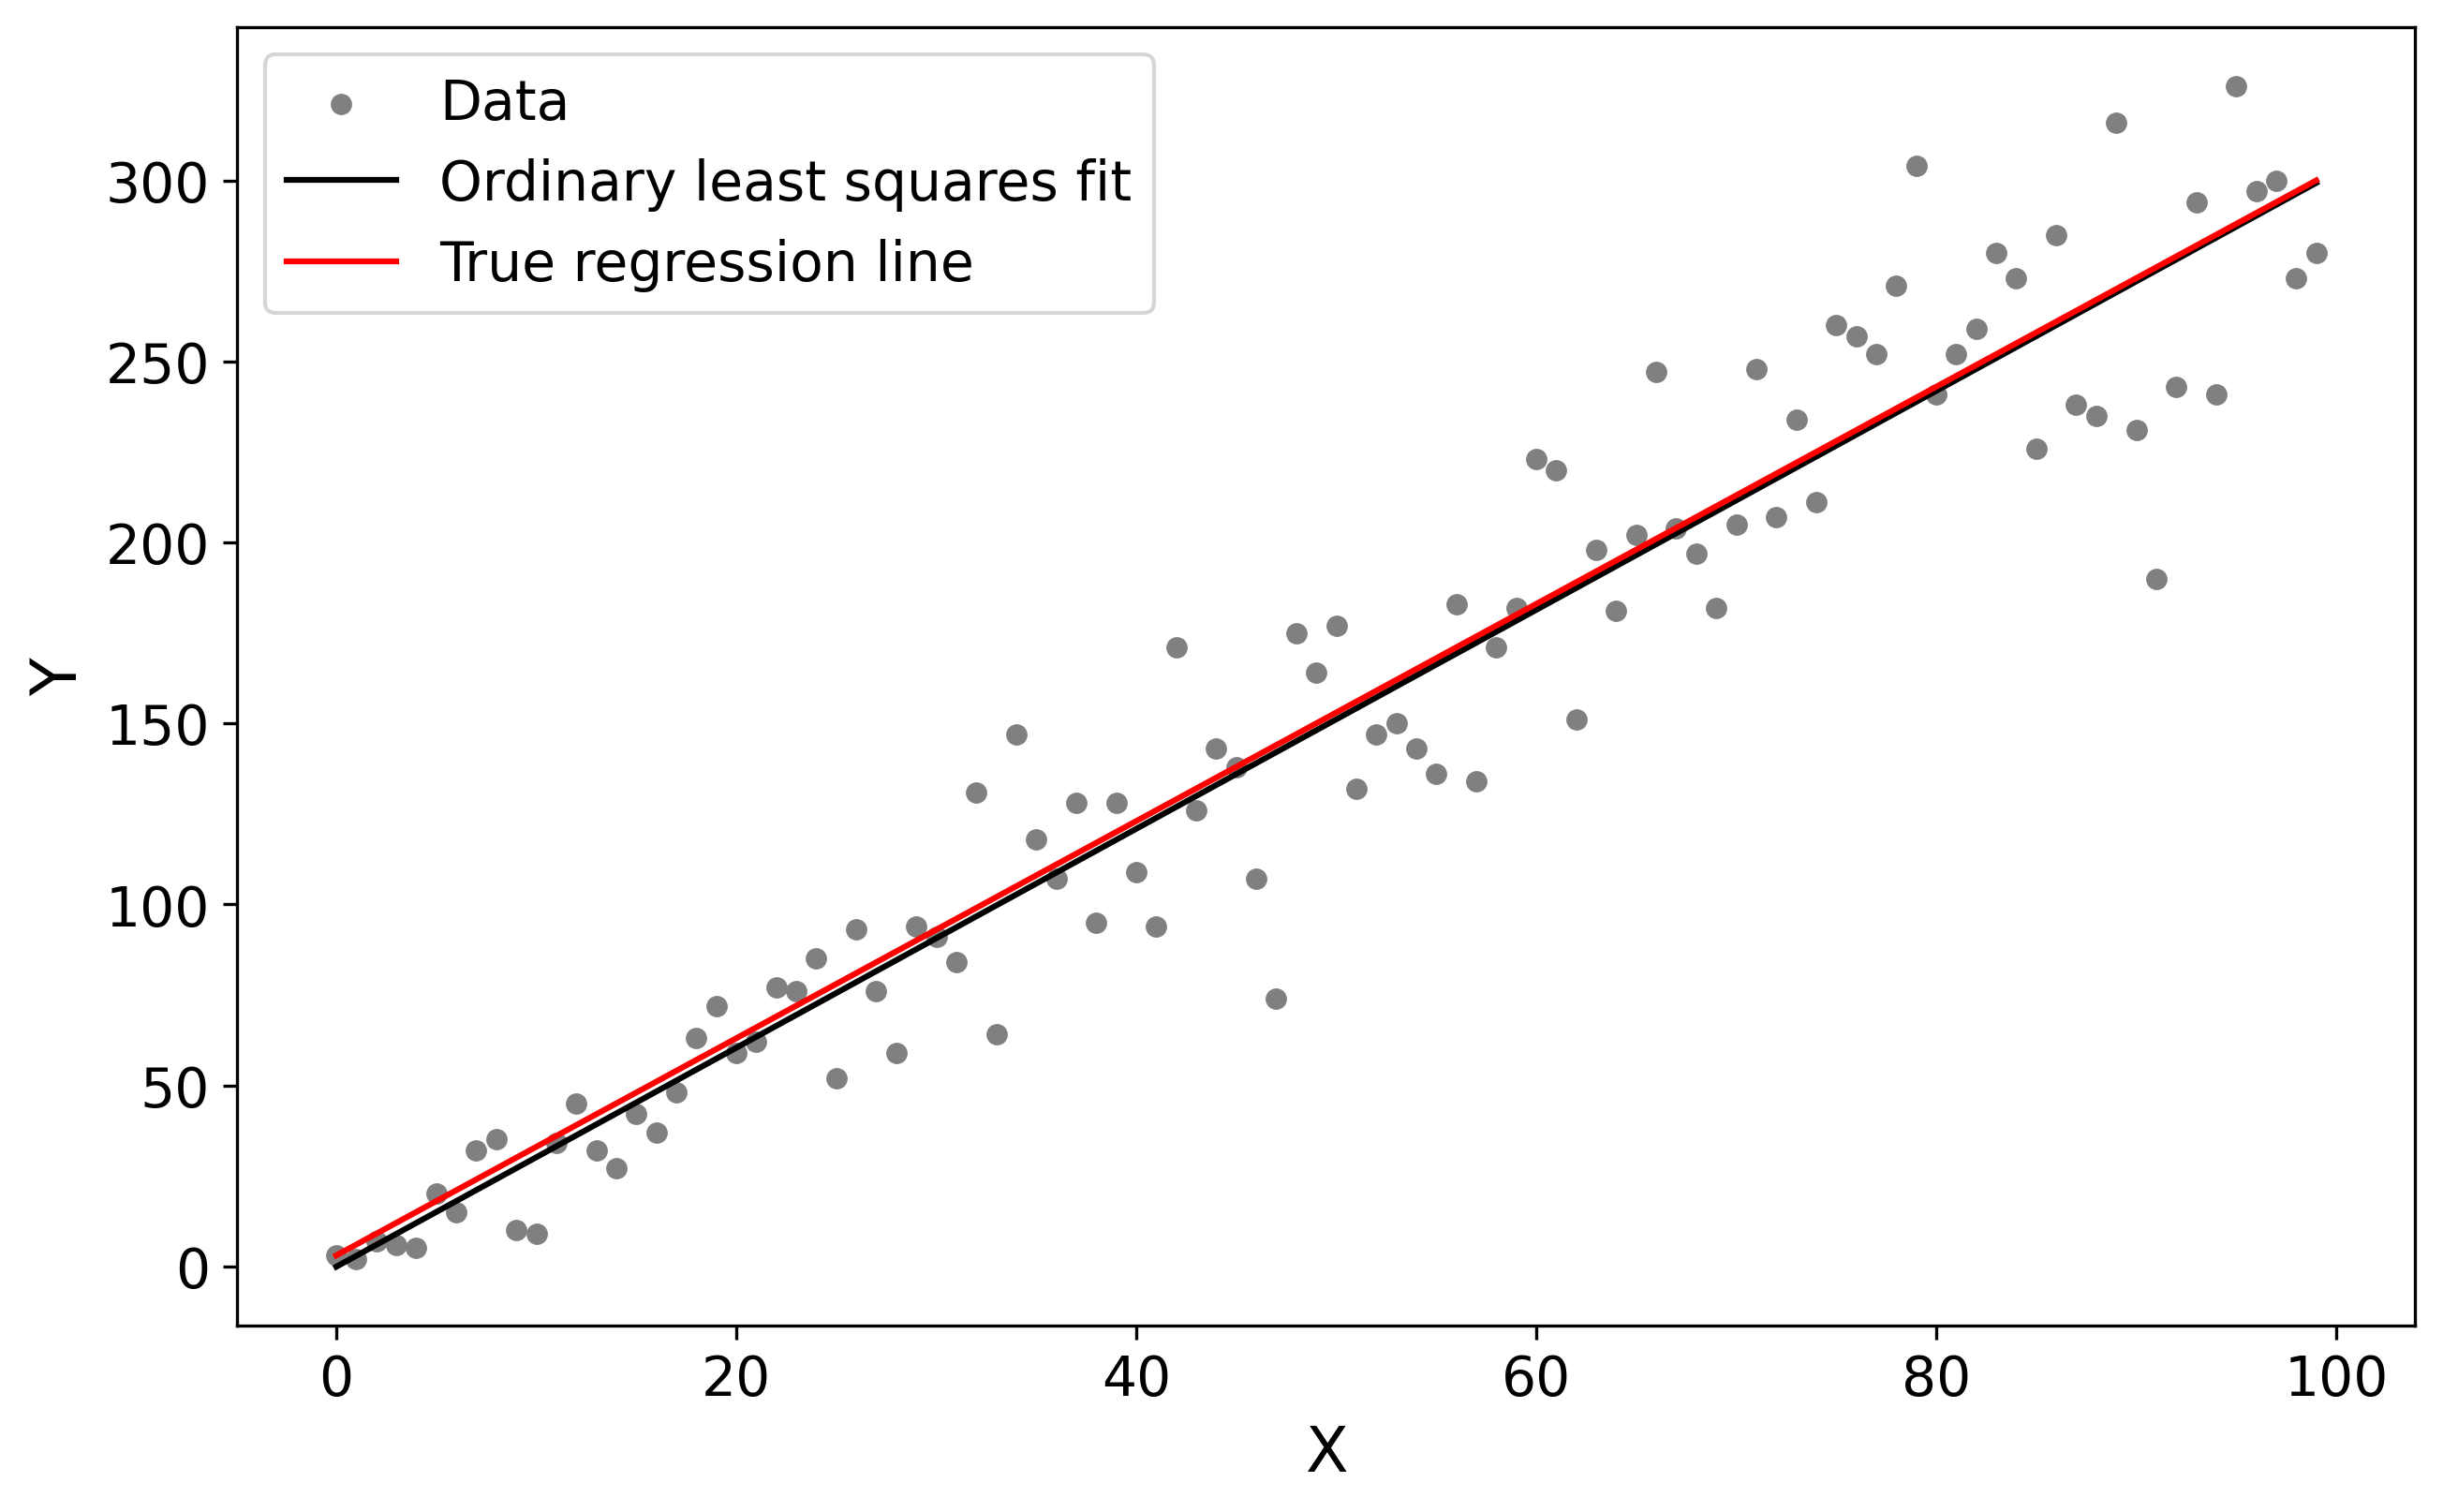

In [8]:
plt.figure(figsize = (10,6))
plt.scatter(x,yp, s = 20, c = 'gray', label = 'Data')
plt.plot(x, slope*x + intercept, c ='k', label = 'Ordinary least squares fit')
plt.plot(x, 3*x + 3, c = 'r', label = 'True regression line')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Pregunta

Compara los coeficientes ajustados con los valores verdaderos $\beta_0=3$ y $\beta_1=3$
-  ¿Son exactamente iguales? ¿Por qué?

Los coeficientes ajustados no son exactamente iguales a los valores verdaderos. Esto se debe a que los datos simulados incluyen ruido, y el modelo de regresión lineal busca el mejor ajuste a estos datos observados, que contienen esa variabilidad, en lugar de la relación subyacente perfecta.

-  ¿Qué representa físicamente/matemáticamente la pendiente en este modelo?

Matemáticamente, la pendiente representa la tasa de cambio en la variable dependiente por cada unidad de cambio en la variable independiente.

#### Solución analítica de mínimos cuadrados

Para regresión lineal simple, la pendiente que minimiza el MSE puede escribirse como:

$$
\beta_1 =
\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}
{\sum_i (x_i-\bar{x})^2}
$$

y luego:

$$
\beta_0 = \bar{y} - \beta_1\bar{x}
$$

**Implemente en el código para calcular a partir de la solución analítica los coeficientes y compare**

In [12]:
x_bar = np.mean(x)
y_bar = np.mean(yp)

beta1 = np.sum((x - x_bar) * (yp - y_bar)) / np.sum((x - x_bar)**2)
beta0 = y_bar - beta1 * x_bar

print(f"Beta_0 analítico = {beta0:.3f}")
print(f"Beta_1 analítico = {beta1:.3f}")

Beta_0 analítico = -0.126
Beta_1 analítico = 3.025


#### Evaluación del modelo: validación cruzada y métricas

Ahora aplicamos una idea que ya usamos en clasificación: validar el modelo en distintos subconjuntos de datos.

Por defecto, `LinearRegression.score()` devuelve \(R^2\), no accuracy.

Podemos ver todos los scorers implementados en sklearn

In [13]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

#### Implemente una validación cruzada con Kfold

y encuentre los resultados para las métricas R^2, 'neg_mean_absolute_error'  (MAE) y 'neg_mean_squared_error' (MSE)

Para los estimadores de la performance del modelo del tipo "error" siempre queremos que sean pequeños (menor error, mejor modelo). Pero en sklearn, reciben un signo negativo, como neg_mean_squared_error, para mantener la consistencia de "alto puntaje=mejor" de los scorers

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
scores_r2 = cross_validate(...)#implemente una validacion cruzada
print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

In [15]:
scores_r2 = cross_validate(model, x.reshape(-1, 1), yp, cv=kf, scoring='r2', return_train_score=True)
print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

R2 test : 0.903 ± 0.059
R2 train: 0.925 ± 0.007


In [16]:
scores_mse = cross_validate(model, x.reshape(-1, 1), yp, cv=kf, scoring='neg_mean_squared_error')
scores_mae = cross_validate(model, x.reshape(-1, 1), yp, cv=kf, scoring='neg_mean_absolute_error')

print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")

MSE test: 633.964
MAE test: 19.067


**Haga un gráfico de los residuos $r_i=y_i-\hat{y}_i$**

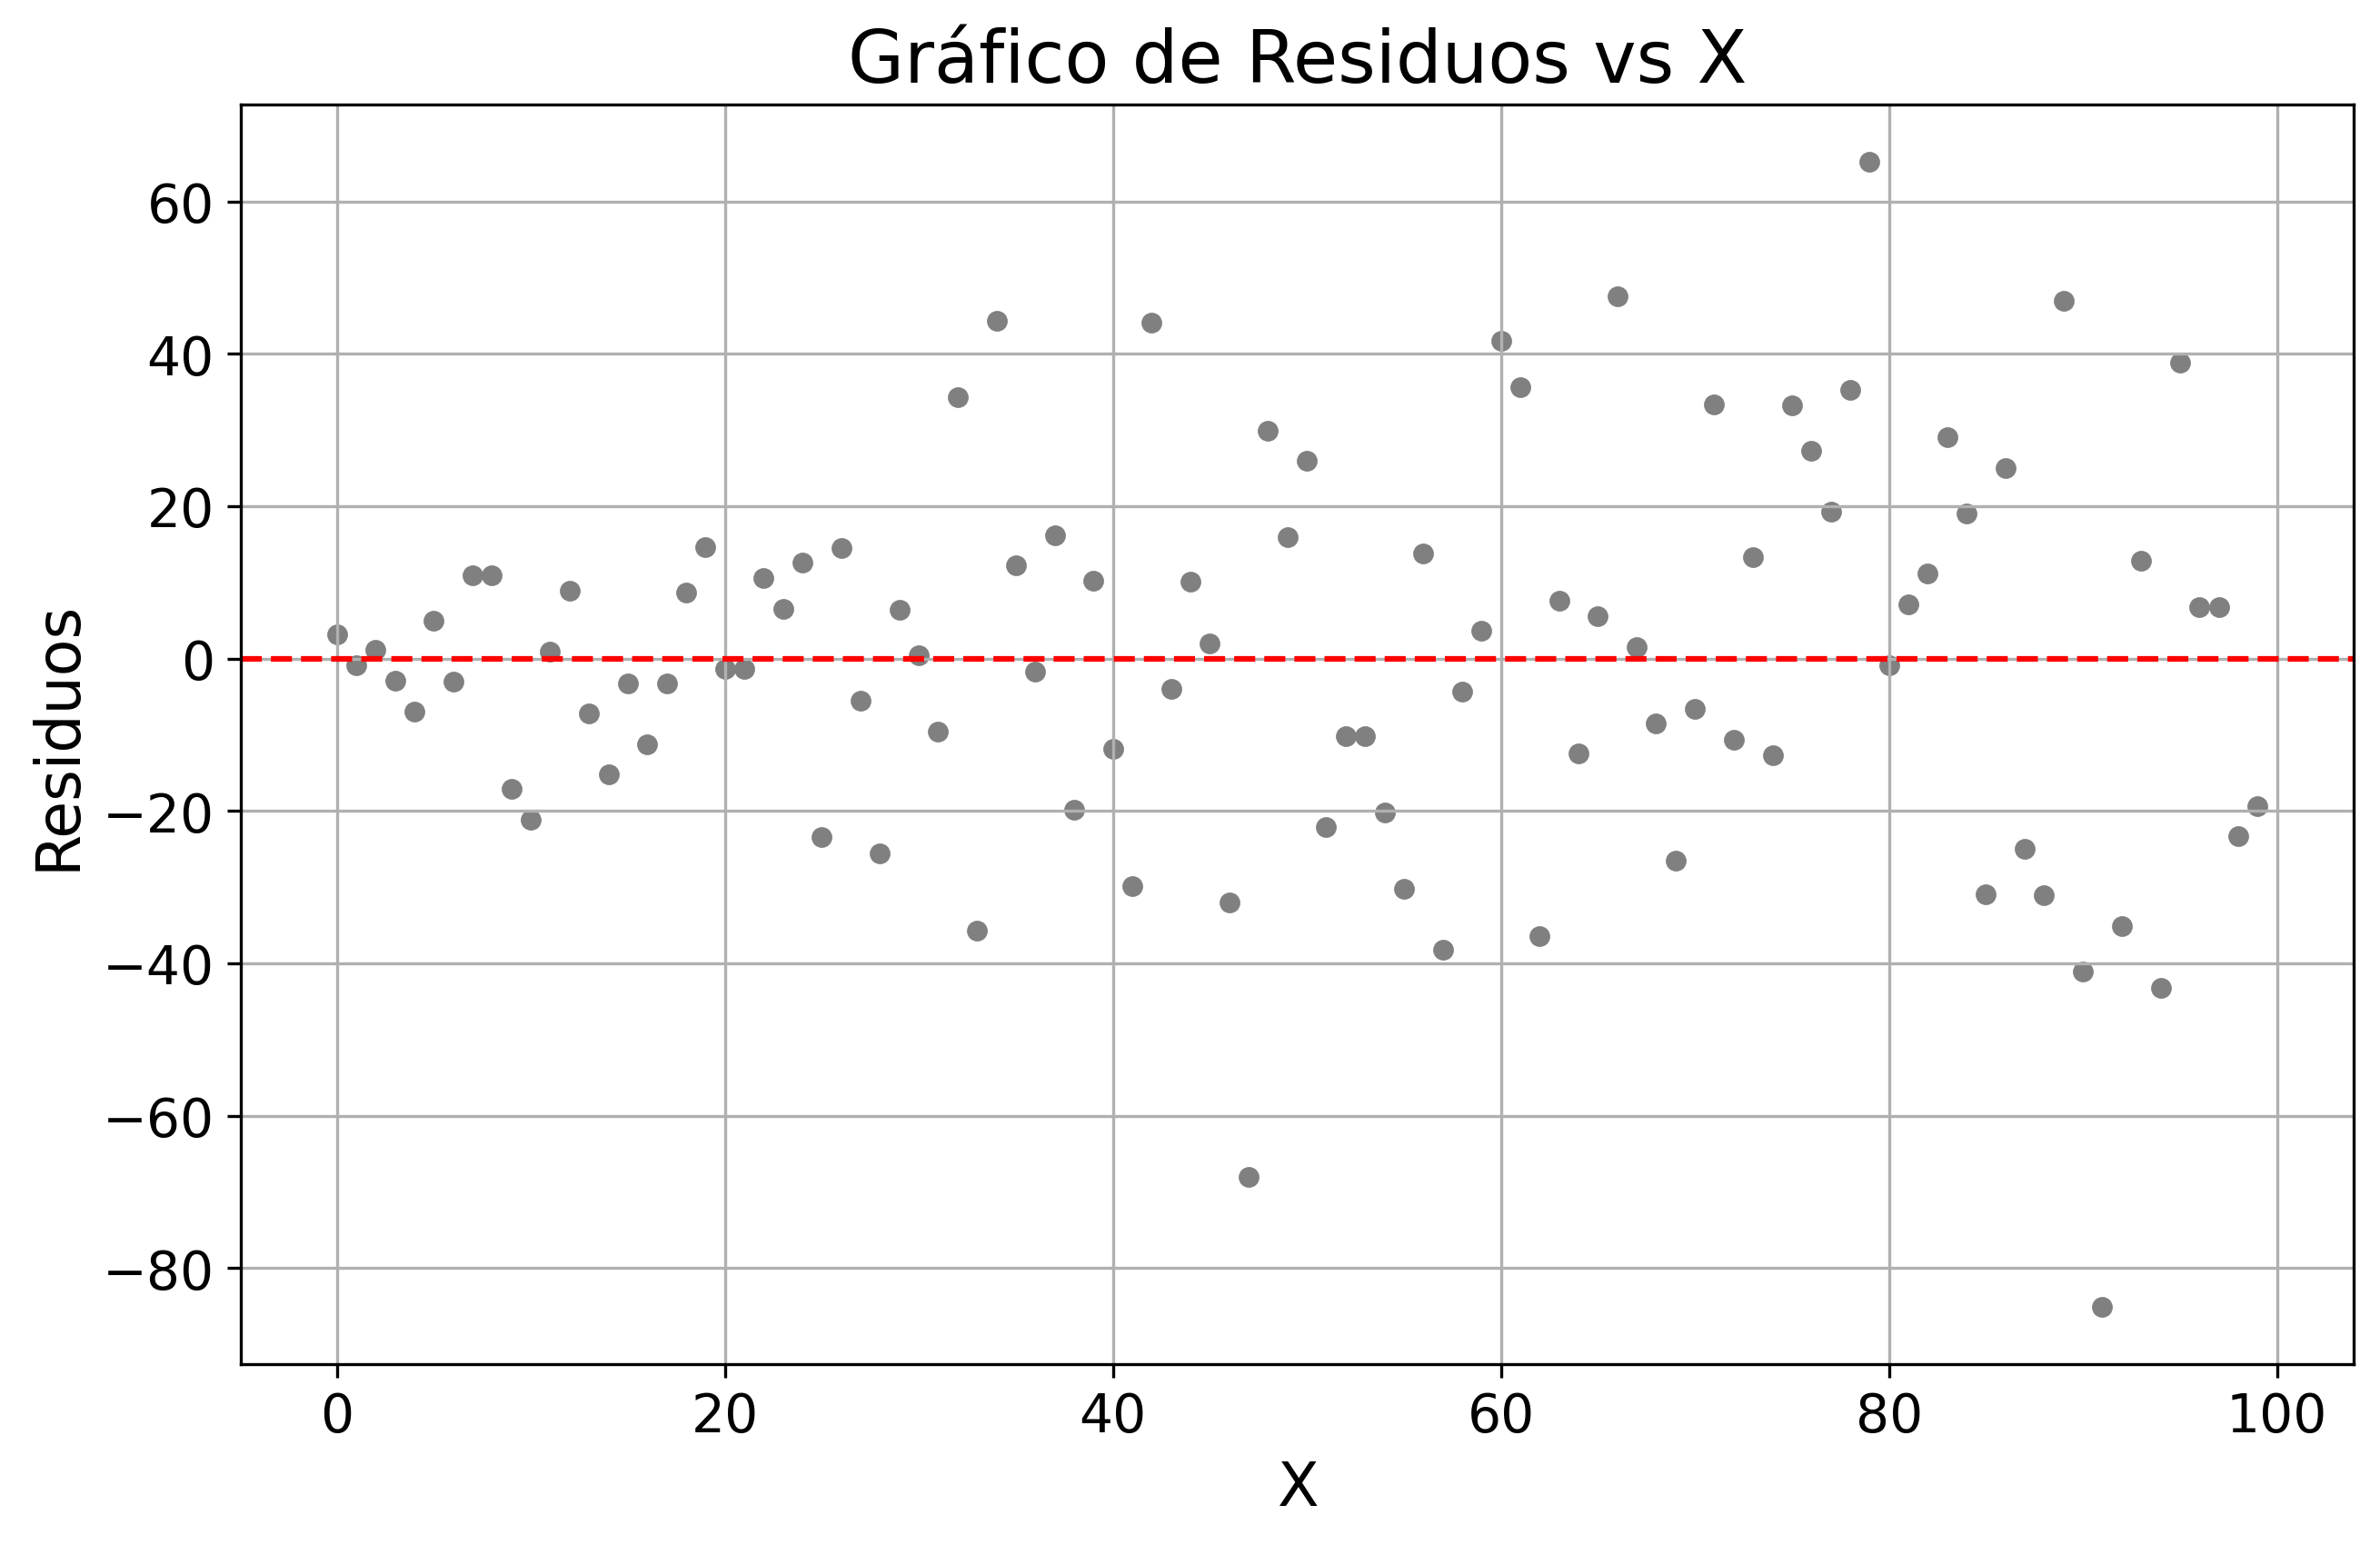

In [17]:
y_hat = model.predict(x.reshape(-1, 1))
residuals = yp - y_hat

plt.figure(figsize=(10, 6))
plt.scatter(x, residuals, s=20, c='gray')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('X')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos vs X')
plt.grid(True)
plt.show()

#### Pregunta
-  ¿Los residuos parecen distribuidos aleatoriamente alrededor de cero?

No, los residuos no parecen estar distribuidos aleatoriamente alrededor de cero.

-  ¿La dispersión de los residuos cambia con $x$?

Sí, la dispersión de los residuos claramente aumenta a medida que $x$ aumenta.

-  ¿Qué nos dice esto sobre el modelo y/o sobre cómo fueron generados los datos?

Esto nos indica la presencia de heterocedasticidad. Lo que es consistente con el proceso de generación de datos que incluía ruido Poissoniano, donde la varianza es igual a la media (que en este caso depende de x).


### ¿Qué ocurre si agregamos outliers?

In [18]:
np.random.seed(12) # fijada la semilla
out = np.random.choice(100,15) #seleccionamos 15 índices de outliers
yp_wo = np.copy(yp)
np.random.seed(12) #fijada
yp_wo[out] = yp_wo[out] + 5*np.random.rand(15)*yp[out]

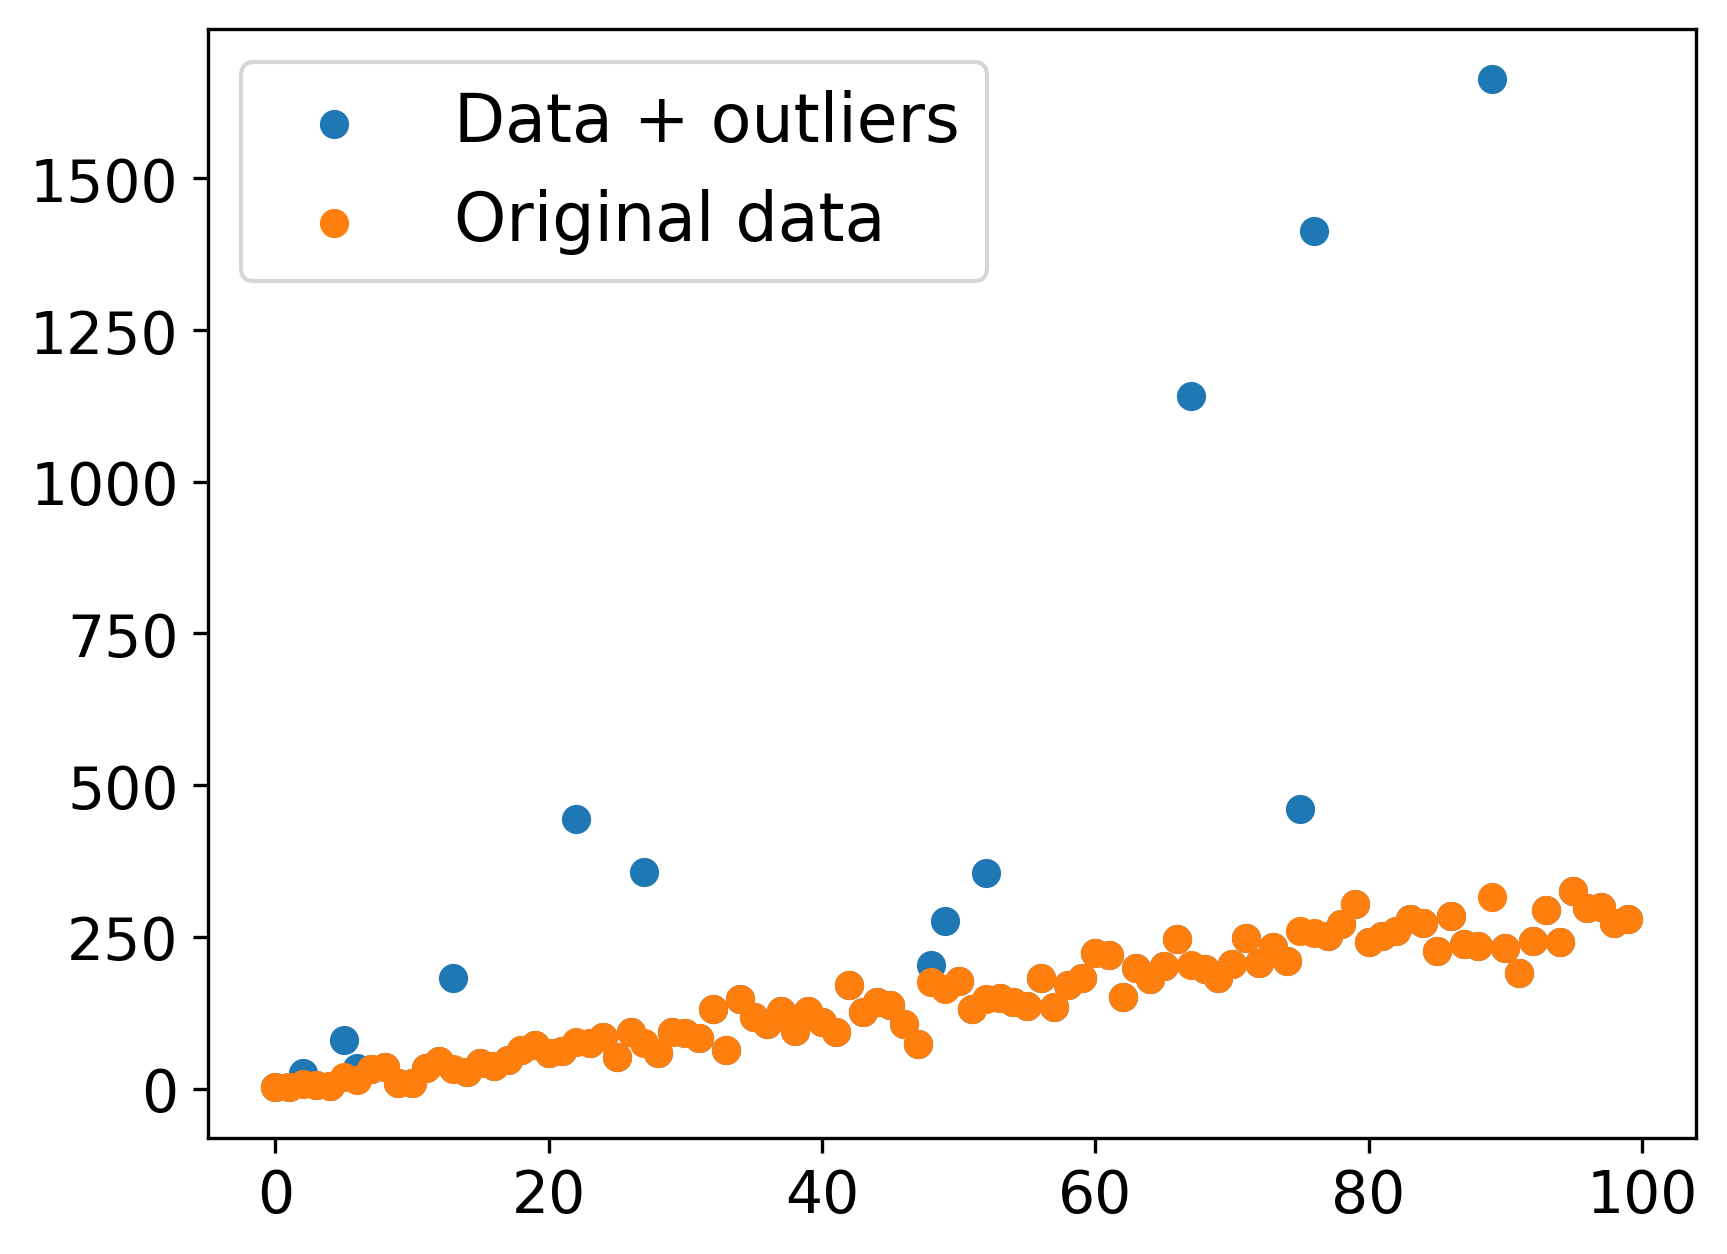

In [19]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.legend();

#### Ajuste el modelo de regresión lineal para los datos con outliers

Responda:
- Compare visualmente el ajuste antes y después de agregar outliers. ¿La recta cambia mucho? ¿Hacia dónde se mueve?

La recta de regresión cambia mucho. Originalmente, tenía un intercepto cercano a cero y una pendiente de 3.025. Con los outliers, el intercepto ha aumentado a 1.548 y la pendiente a 3.978. La recta se ha levantado y ha rotado un poco hacia arriba. La línea de ajuste se mueve hacia los outliers.

- Compara los coeficientes $\beta_0$ y $\beta_1$ del modelo con y sin outliers.  ¿Cuál cambia más: el intercepto o la pendiente?

El intercepto cambia de -0.126 a 1.548 (un cambio de 1.674). La pendiente cambia de 3.025 a 3.978 (un cambio de 0.953). Entonces el intercepto es el que más cambia, pero ambos se ven afectados.

- Compara las métricas MAE, MSE, RMSE y $R^2$ antes y después de agregar outliers. ¿Qué métrica se ve más afectada?

$R^2$ tiene una disminuición significativa, MAE se duplicó, MSE se cuadriplicó. La métrica MSE (y por lo tanto RMSE) es la que se ve más afectada.

- ¿Por qué el MSE/RMSE suele ser más sensible a outliers que el MAE?

El MSE y el RMSE son más sensibles a los outliers que el MAE porque el MSE/RMSE eleva al cuadrado la magnitud de los errores.

- ¿Todos los outliers afectan de la misma manera al modelo? Observa si los puntos atípicos están lejos en $y$, lejos en $x$, o en ambos.

Los outliers fueron generados modificando los valores de yp mientras se mantienen los valores de x originales. Esto significa que los puntos atípicos están principalmente lejos en y. La forma en que un outlier afecta al modelo depende de su apalancamiento y su discrepancia. Los outliers con alto apalancamiento pueden tener una influencia muy fuerte en la pendiente de la regresión.

- ¿Dirías que el modelo con outliers está aprendiendo la tendencia general de los datos o está siendo “tirado” por algunos puntos extremos? Justifica.

El modelo con outliers está siendo “tirado” por algunos puntos extremos. La significativa caída en el R^2 y el gran aumento en el MSE/MAE indican que el modelo ha sacrificado su capacidad de ajustarse bien a la mayoría de los datos para intentar acomodar los puntos atípicos. La recta de regresión ya no representa la tendencia general de la mayoría de los datos de manera óptima.

- Si este fuera un dataset real, ¿eliminarías los outliers automáticamente? Explica qué revisarías antes de decidir.

No, antes de decidir eliminarlos, revisaría el origen del outlier, el impacto en el modelo, conocimiento del dominio y métodos alternativos.


In [24]:
model_outliers = linear_model.LinearRegression()
model_outliers.fit(x.reshape(-1, 1), yp_wo)

LinearRegression()

Del resultado del modelo lineal para estos datos con outliers, guarde los coeficientes encontrados en un array llamado `theta_ne`

In [25]:
theta_ne = np.array([[model_outliers.coef_[0]],[model_outliers.intercept_]])
print(f"Intercepto beta_0 con outliers = {model_outliers.intercept_:.3f}")
print(f"Pendiente beta_1 con outliers = {model_outliers.coef_[0]:.3f}")

Intercepto beta_0 con outliers = 1.548
Pendiente beta_1 con outliers = 3.978


#### Evaluación del modelo con outliers: validación cruzada y métricas

In [26]:
scores_r2_outliers = cross_validate(model_outliers, x.reshape(-1, 1), yp_wo, cv=kf, scoring='r2', return_train_score=True)
print(f"R2 test con outliers: {scores_r2_outliers['test_score'].mean():.3f} ± {scores_r2_outliers['test_score'].std():.3f}")
print(f"R2 train con outliers: {scores_r2_outliers['train_score'].mean():.3f} ± {scores_r2_outliers['train_score'].std():.3f}")

scores_mse_outliers = cross_validate(model_outliers, x.reshape(-1, 1), yp_wo, cv=kf, scoring='neg_mean_squared_error')
scores_mae_outliers = cross_validate(model_outliers, x.reshape(-1, 1), yp_wo, cv=kf, scoring='neg_mean_absolute_error')

print(f"MSE test con outliers: {-scores_mse_outliers['test_score'].mean():.3f}")
print(f"MAE test con outliers: {-scores_mae_outliers['test_score'].mean():.3f}")

R2 test con outliers: 0.174 ± 0.050
R2 train con outliers: 0.237 ± 0.013
MSE test con outliers: 45022.447
MAE test con outliers: 93.481


#### Visualización del ajuste con y sin outliers

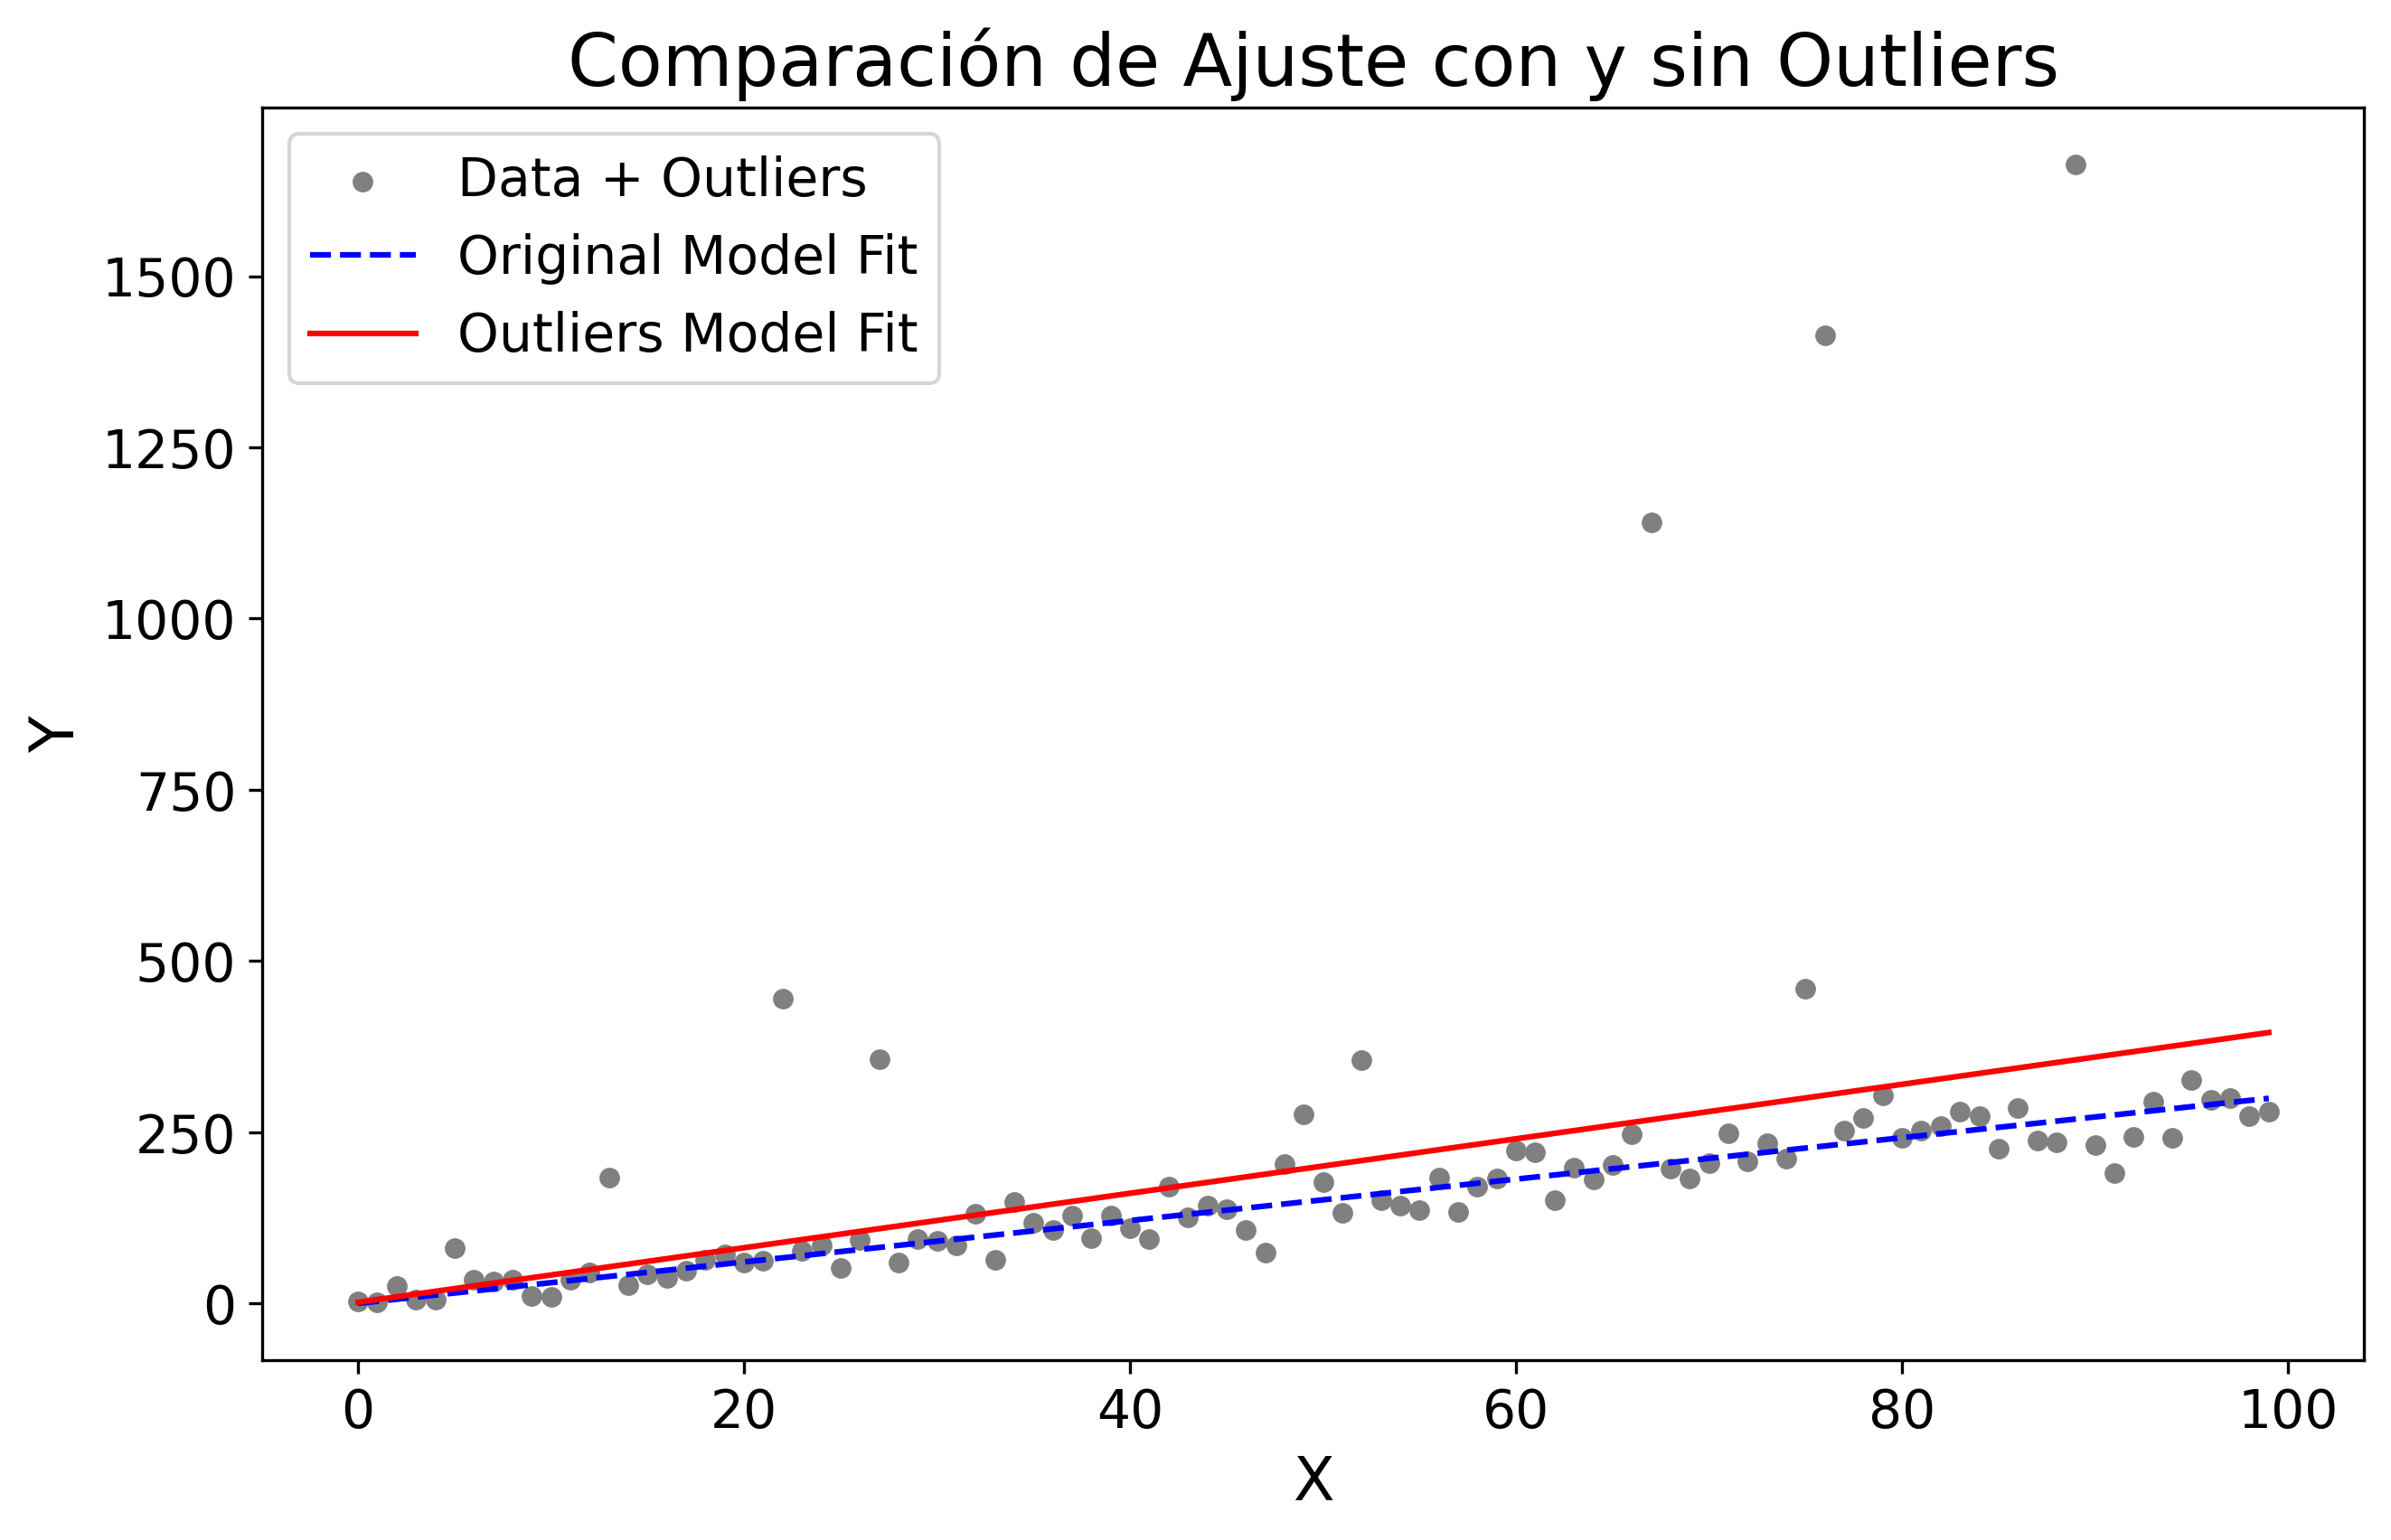

In [27]:
y_hat_original = model.predict(x.reshape(-1, 1))
y_hat_outliers = model_outliers.predict(x.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.scatter(x, yp_wo, s=20, c='gray', label='Data + Outliers')
plt.plot(x, y_hat_original, c='blue', linestyle='--', label='Original Model Fit')
plt.plot(x, y_hat_outliers, c='red', label='Outliers Model Fit')
plt.legend(fontsize=14)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Comparación de Ajuste con y sin Outliers')
plt.show()

Esto es la solución usando el modelo y la **ecuación normal**

### Ahora implementaremos 3 métodos de gradient descent: batch, estocástico y mini-batch

En esta sección ajustamos una regresión lineal usando Gradient Descent en vez de usar directamente `LinearRegression`. Compararemos con los resultados encontrados en la regresión con outliers.




Agregaremos $x_0=1$ a cada instancia, este es el término de bias ($\beta_0$) y se usa para escribir la solución en la forma de multiplicación de matrices

$y=X\cdot \theta$

donde $\theta$ es el vector de coeficientes que incluye el término $\beta_0$  (término de bias) y $\beta_1, \beta_2, \beta_3,..., \beta_n$

In [28]:
X = np.c_[np.ones((100, 1)), x]

print(X.shape) #la forma es el número de instancias x número de parámetros


(100, 2)


Podemos calcular la pérdida asociada con la ecuación normal, usando la expresión

$\text{MSE} = \frac{1}{m}\|X\cdot \theta - y \|^2$

In [29]:
loss_ne = np.mean((X.dot(theta_ne) - yp_wo.reshape(-1,1))**2)

### Batch GD

In [30]:
np.random.seed(10)

eta = 0.0001 #learning step (valor pequeño asegura convergencia, aunque lenta)
n_iterations = 1000 #puede cambiar este valor!!
m = 100 #número de instancias

theta_path_bgd = [] #arreglo para guardar los valores de los parámetros en cada iteración

theta = np.random.randn(2,1) #inicializamos con valores aleatorios

for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta) - yp_wo.reshape(-1,1)) #gradiente de la función de pérdida respecto a theta
    theta = theta - eta * gradients #actualiza los valores de theta, en cada cálculo del gradiente, en cada paso
    theta_path_bgd.append(theta) #

theta_path_bgd = np.array(theta_path_bgd) #guardamos esos valores (útil para una visualización)

theta_bgd = theta #resultado final

In [31]:
theta_bgd

array([[1.38909891],
       [3.98081931]])

In [32]:
loss_bgd = np.sum(1/m*(X.dot(theta_bgd) - yp_wo.reshape(-1,1))**2)

In [33]:
loss_bgd

np.float64(43259.08804185896)

In [34]:
(loss_ne-loss_bgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(30.310266853466768)

###  GD estocástico

In [35]:
np.random.seed(10) #

theta = np.random.randn(2,1)  #inicializa los parámetros

eta = 0.000005 #learning step, valor más pequeño evita saltos muy grandes

n_iterations = 10000 #necesitamos más iteraciones en este caso

theta_path_sgd = []

for epoch in range(n_iterations):

        random_index = np.random.randint(m) #índice aleatorio

        x_one = X[random_index:random_index+1] #sólo se selecciona una instancia del conjunto de datos (m es la cantidad total)

        y_one = yp_wo[random_index:random_index+1]

        gradients = 2 * x_one.T.dot(x_one.dot(theta) - y_one)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)

theta_path_sgd = np.array(theta_path_sgd)

theta_sgd = theta

In [36]:
theta_sgd

array([[1.3552955 ],
       [4.17721319]])

In [37]:
loss_sgd = np.sum(1/m*(X.dot(theta_sgd) - yp_wo.reshape(-1,1))**2)

In [38]:
loss_sgd

np.float64(43385.08132655123)

In [39]:
(loss_ne-loss_sgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(30.10729358736454)

### Mini batch GD

In [40]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html

np.random.seed(10)

theta = np.random.randn(2,1)

eta = 0.000005

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10

for epoch in range(n_iterations):

    shuffled_indices = np.random.permutation(m) #se desordena el arreglo para seleccionar distintos mini-batches

    X_shuffled = X[shuffled_indices]

    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]

    xi = X_shuffled[:minibatch_size] #subset aleatorio para calcular el gradiente

    yi = y_shuffled[:minibatch_size]

    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)

    theta = theta - eta * gradients

    theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta

print(theta_mgd)

[[1.38191988]
 [4.25542902]]


In [41]:
theta_mgd

array([[1.38191988],
       [4.25542902]])

In [42]:
loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)

In [43]:
loss_mgd

np.float64(43506.50418469318)

In [44]:
(loss_ne-loss_mgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(29.911683208948485)

#### Comparación de GD
Veamos el camino que siguió cada método de GD que implementamos. El color más oscuro indica pasos posteriores

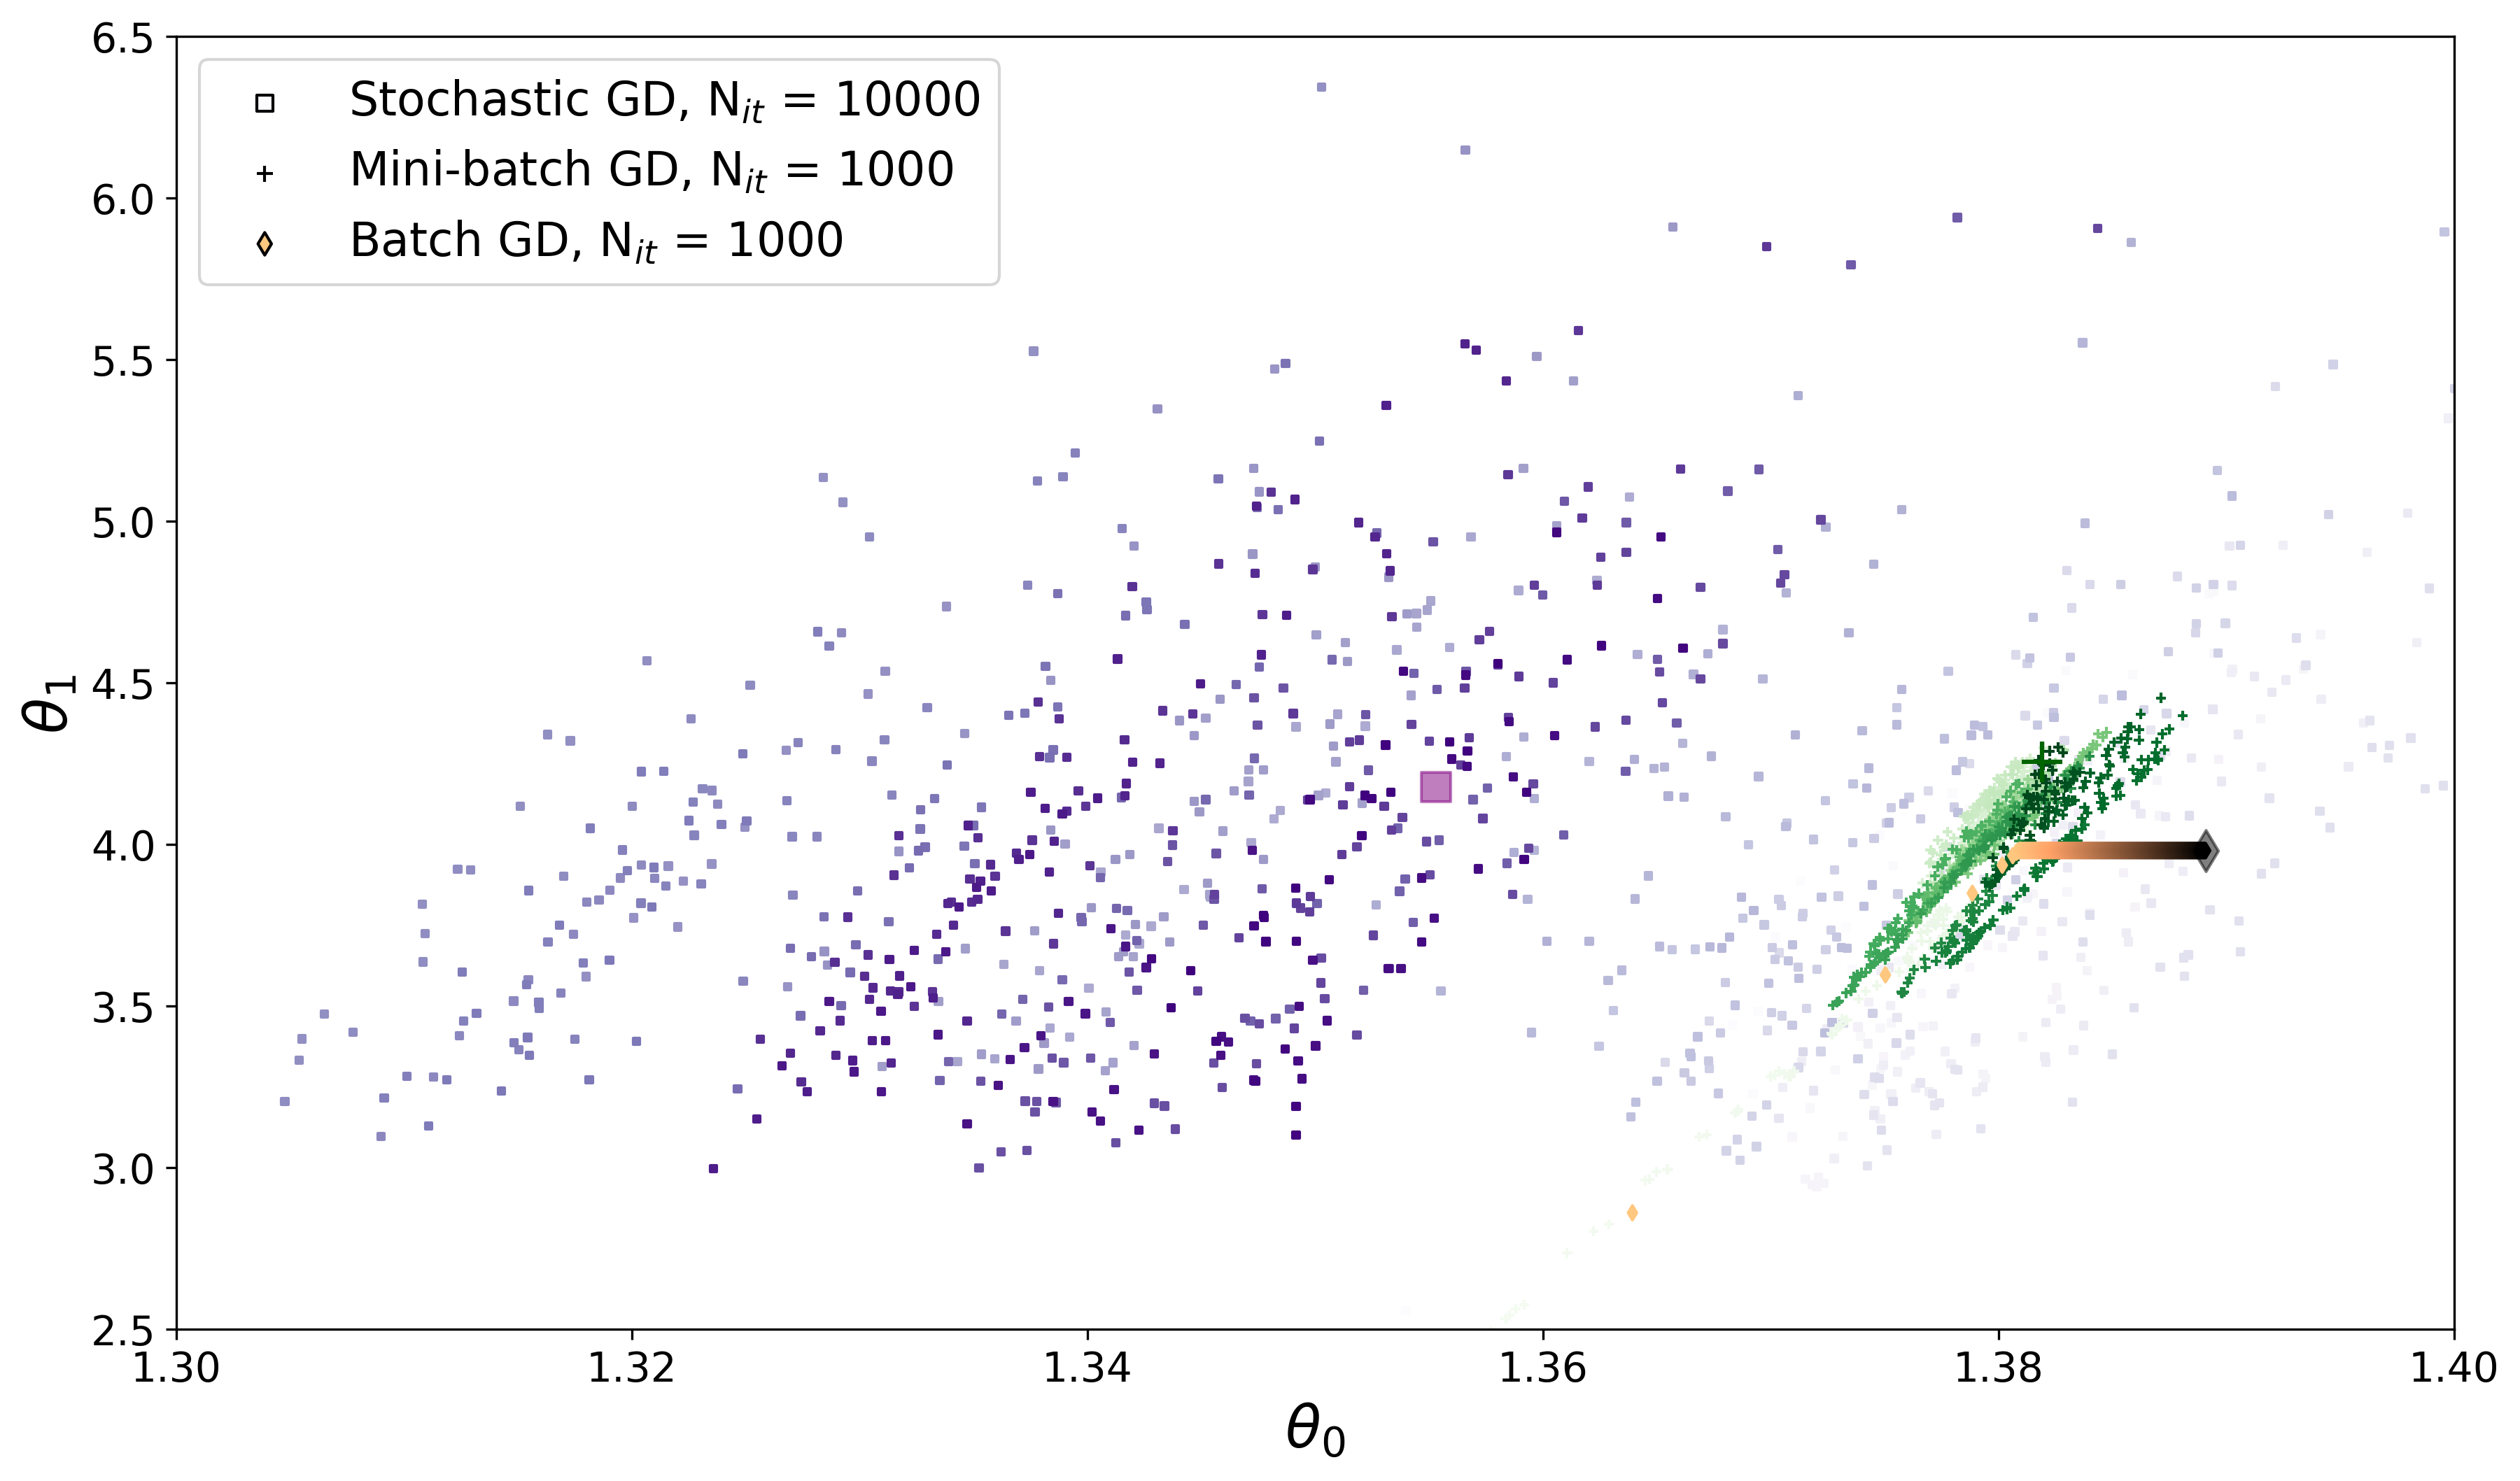

In [47]:
plt.figure(figsize=(14,8))

plt.scatter(theta_path_sgd[::10, 0].flatten(), theta_path_sgd[::10, 1].flatten(), marker = 's', s = 5, \
         label="Stochastic GD, N$_{it}$ = 10000", c = np.arange(1000), cmap=plt.cm.Purples)
plt.scatter(theta_path_mgd[:, 0].flatten(), theta_path_mgd[:, 1].flatten(), marker = "+", s = 12, linewidth=1, \
            label="Mini-batch GD, N$_{it}$ = 1000", c = np.arange(1000), cmap=plt.cm.Greens)
plt.scatter(theta_path_bgd[:, 0].flatten(), theta_path_bgd[:, 1].flatten(), marker = "d", s = 12, linewidth=1, \
            label="Batch GD, N$_{it}$ = 1000", c = np.arange(1000,0,-1), cmap=plt.cm.copper)

plt.scatter(theta_sgd[0],theta_sgd[1], marker = "s", s = 100, color = 'Purple', alpha = 0.5)
plt.scatter(theta_mgd[0],theta_mgd[1], marker = "+", s = 200, color = 'DarkGreen', alpha = 1)
plt.scatter(theta_bgd[0],theta_bgd[1], marker = "d", s = 100, color = 'k', alpha = 0.5)

legend = plt.legend(loc="upper left", fontsize=16)


for i in range(3):
  legend.legend_handles[i].set_color('k')
  legend.legend_handles[i].set_sizes([30])

plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$   ", fontsize=20)

plt.axis([1.3, 1.4, 2.5, 6.5])

#plt.savefig('AllThePaths.png', dpi = 300)
plt.show()

### Preguntas

1. Identifica en el código de mini batch GD dónde ocurre cada paso:

   - cálculo de las predicciones:  xi.dot(theta) (dentro de la expresión del gradiente)
   - cálculo del error o residuo: xi.dot(theta) - yi (dentro de la expresión del gradiente)
   - cálculo del gradiente: gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
   - actualización de los parámetros: theta = theta - eta * gradients

2. ¿Qué representan los parámetros $\theta_0$ y $\theta_1$ en este modelo?

En este modelo de regresión lineal simple, $\theta_0$ representa el intercepto y $\theta_1$ representa la pendiente de la recta de regresión. Juntos, definen la línea que mejor se ajusta a los datos.

3. Compara los parámetros encontrados por Gradient Descent con los obtenidos mediante `LinearRegression`. ¿Son iguales o parecidos? ¿Por qué no necesariamente coinciden exactamente?

Los parámetros son parecidos, pero no exactamente iguales. Las razones por las que no coinciden exactamente son la convergencia en GD, su aleatoridad, el Learning Rate y número de iteraciones.


4. Cambia el learning rate $\eta$. Prueba al menos tres valores: uno pequeño, uno razonable y uno demasiado grande. ¿Qué ocurre en cada caso?

$\eta$ pequeño+: La convergencia sería muy lenta. El algoritmo tardaría muchas más iteraciones en acercarse al mínimo, o podría quedarse 'atascado' lejos del mínimo en el número de iteraciones actual. La trayectoria sería muy suave y gradual.

$\eta$ razonable (como los valores actuales): El algoritmo converge de manera efectiva hacia el mínimo en un número razonable de iteraciones. La trayectoria se dirige directamente hacia el mínimo o, en el caso de SGD/MGD, oscila alrededor de él.

$\eta$ demasiado grande: El algoritmo divergirá. Los pasos serán tan grandes que el algoritmo 'saltará' el mínimo, y los valores de la función de costo y los parámetros se alejarán cada vez más del óptimo, posiblemente llevando a NaN o valores muy grandes. La trayectoria en el gráfico de parámetros mostraría saltos erráticos y alejándose del centro.

5. Explica con tus palabras por qué la actualización tiene un signo menos: $\theta \leftarrow \theta - \eta \nabla L$

El signo menos (-) es fundamental porque queremos minimizar la función de pérdida (L). El gradiente apunta en la dirección de mayor ascenso de la función de pérdida. Para movernos hacia el mínimo, necesitamos ir en la dirección opuesta al gradiente. Por lo tanto, restamos el gradiente a los parámetros actuales para movernos hacia el valle de la función de pérdida.

6. En la solución analítica derivamos e igualamos a cero. En Gradient Descent no resolvemos directamente la ecuación.  ¿Qué hacemos en cambio?

En Gradient Descent no resolvemos la ecuación que se obtiene al igualar el gradiente de la función de pérdida a cero directamente. Utilizamos un proceso iterativo, o sea, comenzamos con un conjunto inicial de parámetros aleatorios y en cada paso calculamos el gradiente de la función de pérdida con respecto a esos parámetros. Luego, ajustamos los parámetros moviéndonos en la dirección opuesta al gradiente, con un tamaño de paso controlado por el learning rate. Repetimos este proceso muchas veces, 'descendiendo' gradualmente por la superficie de la función de pérdida hasta que convergemos a un mínimo (o nos acercamos lo suficiente).

7. Compara Batch Gradient Descent, Stochastic Gradient Descent y Mini-batch Gradient Descent.

   - ¿Cuál usa todos los datos en cada actualización?

Batch Gradient Descent (BGD) en cada iteración, calcula el gradiente utilizando todos los datos de entrenamiento. Esto significa que cada paso es muy preciso y se dirige directamente hacia el mínimo (en el caso de funciones convexas).

   - ¿Cuál actualiza los parámetros con más ruido?

Stochastic Gradient Descent (SGD) calcula el gradiente y actualiza los parámetros utilizando solo una instancia de entrenamiento seleccionada aleatoriamente en cada paso. Esto introduce mucho ruido en la dirección del gradiente, haciendo que la trayectoria sea ruidosa, pero permite actualizaciones muy rápidas.

   - ¿Cuál parece converger de forma más suave?

Batch Gradient Descent (BGD),porque utiliza todos los datos para calcular un gradiente preciso en cada paso, su trayectoria hacia el mínimo es la más suave y directa.